(Bulk-ADR)=
# Bulk ADR

We demonstrate here how to solve general advection-diffusion-reaction (ADR) equation in the bulk in the form:

\begin{equation*}
\partial_t u + \nabla\cdot(\vec{b}u - d \nabla u) + cu = f
\end{equation*}

where
- $u$ is the species considered
- $\vec{b}$ is the advection field
- $d$ is the diffusion coefficient
- $c$ is the reaction coefficient
- $f$ is the right-hand side

The differential symbols are $\nabla\cdot, \nabla$ the usual ones.
We start by creating the mesh we will use.

In [9]:
from cosmos.utils.generate_surface_meshes import generate_circle
from ngsolve.webgui import Draw

mesh, _ = generate_circle()
Draw(mesh)


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

Then we need to decide if our simulation will involve moving boundaries or not.\
For the moment we consider fixed boundaries so we use the class `UnsteadyProblem` (contrary to `MovingProblem`) of the `cosmos` package.

This class has to be initialized using the following arguments:
- the mesh
- the time variable `t` (as an `ngsolve` parameter)
- the timestep variable `dt` (as an `ngsolve` parameter)
- the final simulation time `T`

We can use the method `print_mesh_info` to print some useful info on the mesh

In [10]:
from ngsolve import *
from cosmos.solvers.simulation import UnsteadyProblem

dt = Parameter(0.1)
T = 1
t = Parameter(0)
simulation = UnsteadyProblem(mesh=mesh, t=t, dt = dt, T = T)

simulation.print_mesh_info()

------------------------------------------------------------
The mesh is a  2D mesh
The number of:
     vertices is:  388
     edges is:  1099
     faces is:  712
     facets is:  1099
     elements is:  712 ( = 0 if hypersurface)
Regions of co-dimension  0 :
  - There is(are)  1 region(s) called  default
Regions of co-dimension  1 :
  - There is(are)  2 region(s) called  boundary
Regions of co-dimension  2 :
  - There is(are)  2 region(s) called  default
------------------------------------------------------------ 



It's time now to create the solver for our equation.  \
This is done using the `ADRSolver` class of the `cosmos` package. \
The solver has then to be added to the simulation in order to access the time variables and the mesh information

In [11]:
from cosmos.solvers.adr import ADRSolver
solver = ADRSolver(linear = True)
simulation.attach_solver(solver)

At this point we need to prescribe the coefficients of our solver. \
We create a manufactured solution so that later we can use it to perform convergence studies

In [12]:
from cosmos.utils.manufactured_solution_tools import gradient

u_ex = cos(pi*x)*sin(pi*y)*cos(t)
d = 1 + x**2
c = 1 +y**2
b = CF((2,sin(x)))
flux1 = (b*u_ex).Compile()
flux2 = (- d*gradient(u_ex, Id(2))).Compile()
flux = flux1 + flux2
rhs = (u_ex.Diff(t) + Trace(gradient(flux, Id(2))) + c*u_ex).Compile()

In the above:
- `flux1` is the flux due to the advective term
- `flux2` is the flux due to the diffusive term
This allows us to define various types of boundary conditions.

In particular we can prescribe:
- Dirichlet boundary conditions
- Neumann boundary conditions

The way the solver works is that this information is passed using dictionaries as follows

In [13]:
neu_b = {'boundary': flux1}
neu_d = {'boundary': flux2}
dir_d = {'boundary': u_ex}
dir_b = {'boundary': u_ex}

We then proceed to add the parameters to the solver. \
Subsequently we add the solver to the simulation. The simulation itself can contain multiple isolated solvers that share the time variables.



In [14]:
## Using Dirichlet boundary conditions
solver.AddSpecie(VorB = VOL,
                rhs = rhs,
                diffusion = d,
                reaction = c,
                advection = b,
                u0 = u_ex,
                dir_b = dir_b,
                dir_d = dir_d)

# ## Using Neumann boundary conditions
# solver.AddSpecie(VorB = VOL,
#                 rhs = rhs,
#                 advection = b,
#                 diffusion = d,
#                 reaction = c,
#                 u0 = u_ex,
#                 neu_b = neu_b,
#                 neu_d = neu_d)

We can finally run the simulation and plot the final result, comparing it with the exact solution

In [15]:
from ngsolve.webgui import Draw

simulation.run()
print('Computed solution')
solver.draw_solution()
print('Exact solution')
Draw(u_ex, mesh)

Running Simulation...: 100%|███████████████| 10/10 [00:00<00:00, 44.50it/s]

Computed solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Exact solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

Additionally we can compute the error between the two solutions at every time-step. \
The software gives the option of computing either the $L^2$ or the $H^1$ norm between an exact solution and the discrete one

[0.008566356911635415, 0.014710389797547747, 0.016644597093163186, 0.01694004416425733, 0.016605629373552755, 0.015953632285680277, 0.015091239421063232, 0.014060805536992764, 0.012884127999730542, 0.011576964534831346, 0.010153852759895813]


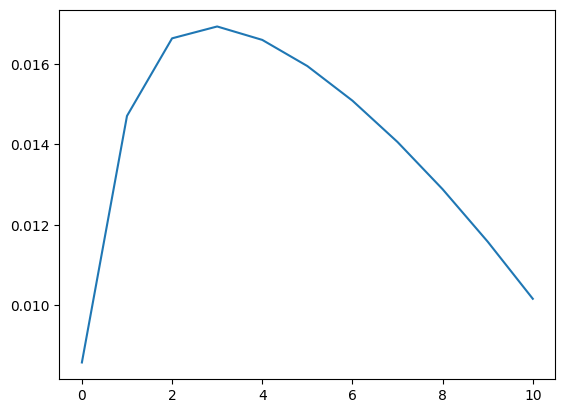

In [16]:
err = solver.compute_error(u_ex, 'L2')
print(err)

import matplotlib.pyplot as plt
plt.plot(err)